<a href="https://colab.research.google.com/github/Zainab-Binte-Khalid/urdu-ocr-codesaviours-si26-zainab/blob/main/SI26_Week1_Zainab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 Research Task

## 1. What is OCR (Optical Character Recognition)?

Optical Character Recognition (OCR) is a technology that converts text from images, scanned documents, or photographs into editable and searchable digital text. It helps computers recognize printed or handwritten characters without typing them manually. OCR is widely used to digitize books, forms, receipts, and historical documents.

## 2. Why is Urdu OCR harder than English OCR?

Urdu OCR is more difficult than English OCR because Urdu is written in a connected script, where the shape of letters changes depending on their position in a word. Urdu also contains many dots and special marks that can be difficult for a computer to identify accurately. Different fonts, handwriting styles, and image quality make Urdu OCR even more challenging.

## 3. What are two real-world situations where Urdu OCR would be useful?

One use of Urdu OCR is converting printed Urdu books, newspapers, and old documents into editable digital text for preservation and searching. Another use is reading information from government forms, educational documents, or business records written in Urdu so the information can be stored and processed electronically.


In [1]:
!pip install Pillow arabic-reshaper python-bidi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 14.4 MB/s eta 0:00:00


In [11]:
!pip install Pillow arabic-reshaper python-bidi


In [13]:
!wget -q https://github.com/google/fonts/raw/main/ofl/notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf -O urdu_font1.ttf
!wget -q https://github.com/google/fonts/raw/main/ofl/notonaskharabic/NotoNaskhArabic%5Bwght%5D.ttf -O urdu_font2.ttf


In [14]:
from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import os
import random

# Base Urdu sentences — add more of your own here
urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "علم انسان کی پہچان ہے",
    "وقت کی قدر کرنی چاہیے",
    "صحت ہزار نعمت ہے",
]

fonts = ['urdu_font1.ttf', 'urdu_font2.ttf']
font_sizes = [28, 32, 36, 40]

os.makedirs('data/synthetic', exist_ok=True)

count = 0
labels = []  # keep track of image -> ground truth text, needed for OCR training

for i, text in enumerate(urdu_texts):
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    # Generate 3 variations per sentence (different font + size + slight jitter)
    for v in range(3):
        font_path = random.choice(fonts)
        font_size = random.choice(font_sizes)
        font = ImageFont.truetype(font_path, font_size)

        # Canvas size scales with font size so text isn't clipped
        img_w, img_h = 550, 100
        img = Image.new('RGB', (img_w, img_h), color='white')
        draw = ImageDraw.Draw(img)

        bbox = draw.textbbox((0, 0), bidi_text, font=font)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]

        # Centered position with small random jitter for variety
        x = (img_w - text_width) / 2 + random.randint(-10, 10)
        y = (img_h - text_height) / 2 + random.randint(-5, 5)

        draw.text((x, y), bidi_text, fill='black', font=font)

        count += 1
        filename = f'data/synthetic/urdu_{count:03d}.png'
        img.save(filename)
        labels.append((filename, text))
        print(f'Generated: {filename} -- {text}')

# Save labels file — critical for OCR training (image-to-text ground truth pairs)
with open('data/synthetic/labels.txt', 'w', encoding='utf-8') as f:
    for filename, text in labels:
        f.write(f'{filename}\t{text}\n')

print(f'\nDone! Generated {count} images in data/synthetic/')
print('Labels saved to data/synthetic/labels.txt')


Generated: data/synthetic/urdu_001.png -- پاکستان زندہ باد
Generated: data/synthetic/urdu_002.png -- پاکستان زندہ باد
Generated: data/synthetic/urdu_003.png -- پاکستان زندہ باد
Generated: data/synthetic/urdu_004.png -- آج کا موسم خوشگوار ہے
Generated: data/synthetic/urdu_005.png -- آج کا موسم خوشگوار ہے
Generated: data/synthetic/urdu_006.png -- آج کا موسم خوشگوار ہے
Generated: data/synthetic/urdu_007.png -- تعلیم ہر انسان کا حق ہے
Generated: data/synthetic/urdu_008.png -- تعلیم ہر انسان کا حق ہے
Generated: data/synthetic/urdu_009.png -- تعلیم ہر انسان کا حق ہے
Generated: data/synthetic/urdu_010.png -- کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: data/synthetic/urdu_011.png -- کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: data/synthetic/urdu_012.png -- کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: data/synthetic/urdu_013.png -- محنت کامیابی کی کنجی ہے
Generated: data/synthetic/urdu_014.png -- محنت کامیابی کی کنجی ہے
Generated: data/synthetic/urdu_015.png -- محنت کامیابی کی کنجی ہے
Generat

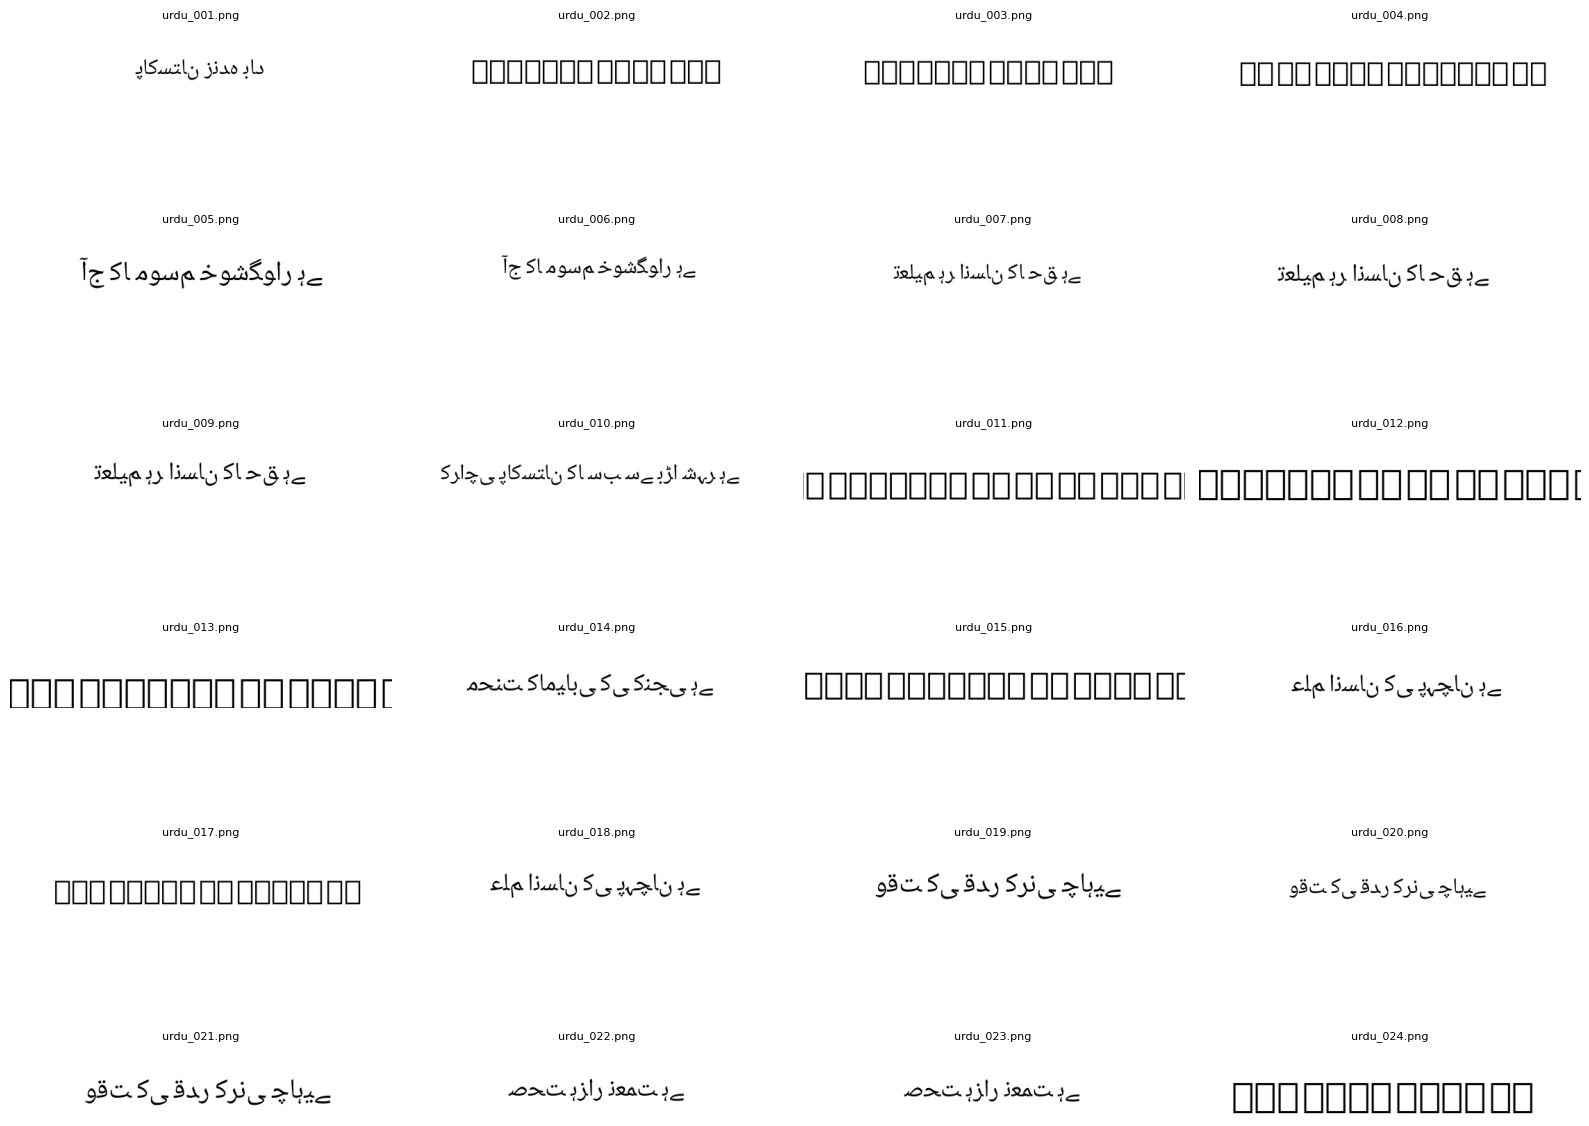

Displayed 24 images from data/synthetic


In [15]:
# Cell 4 — Display generated images in a grid
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

image_dir = 'data/synthetic'
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])

# Load labels for captions
labels_dict = {}
with open(os.path.join(image_dir, 'labels.txt'), 'r', encoding='utf-8') as f:
    for line in f:
        path, text = line.strip().split('\t')
        labels_dict[os.path.basename(path)] = text

n = len(image_files)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(16, rows * 2.2))

for idx, fname in enumerate(image_files):
    img = mpimg.imread(os.path.join(image_dir, fname))
    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    plt.title(fname, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f'Displayed {n} images from {image_dir}')

In [16]:
# Cell 2 — Download Urdu fonts (static versions only, no variable fonts)
!wget -q https://github.com/google/fonts/raw/main/ofl/notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf -O urdu_font1.ttf

# Static Naskh alternative (Jameel Noori Nastaleeq is also a good static option if you prefer)
!wget -q https://github.com/notofonts/arabic/raw/main/fonts/NotoNaskhArabic/hinted/ttf/NotoNaskhArabic-Regular.ttf -O urdu_font2.ttf

# Verify both downloaded successfully (should be >0 bytes, ideally >100KB)
!ls -lh urdu_font1.ttf urdu_font2.ttf

-rw-r--r-- 1 root root 675K Jun 30 14:58 urdu_font1.ttf
-rw-r--r-- 1 root root    0 Jun 30 14:58 urdu_font2.ttf


In [17]:
# Cell 2 — Download Urdu font
!wget -q "https://github.com/google/fonts/raw/main/ofl/notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf" -O urdu_font1.ttf
!ls -lh urdu_font1.ttf

-rw-r--r-- 1 root root 675K Jun 30 15:01 urdu_font1.ttf


In [18]:
# Cell 3 — Generate synthetic Urdu OCR training images
from PIL import Image, ImageDraw, ImageFont
import os
import random

urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "علم انسان کی پہچان ہے",
    "وقت کی قدر کرنی چاہیے",
    "صحت ہزار نعمت ہے",
]

font_sizes = [28, 32, 36, 40]
os.makedirs('data/synthetic', exist_ok=True)

count = 0
labels = []

for text in urdu_texts:
    for v in range(3):
        font_size = random.choice(font_sizes)
        font = ImageFont.truetype('urdu_font1.ttf', font_size, layout_engine=ImageFont.Layout.RAQM)

        img_w, img_h = 550, 100
        img = Image.new('RGB', (img_w, img_h), color='white')
        draw = ImageDraw.Draw(img)

        bbox = draw.textbbox((0, 0), text, font=font, direction='rtl')
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]

        x = (img_w - text_width) / 2 + random.randint(-10, 10)
        y = (img_h - text_height) / 2 + random.randint(-5, 5)

        draw.text((x, y), text, fill='black', font=font, direction='rtl')

        count += 1
        filename = f'data/synthetic/urdu_{count:03d}.png'
        img.save(filename)
        labels.append((filename, text))
        print(f'Generated: {filename} -- {text}')

with open('data/synthetic/labels.txt', 'w', encoding='utf-8') as f:
    for filename, text in labels:
        f.write(f'{filename}\t{text}\n')

print(f'\nDone! Generated {count} images')

Generated: data/synthetic/urdu_001.png -- پاکستان زندہ باد
Generated: data/synthetic/urdu_002.png -- پاکستان زندہ باد
Generated: data/synthetic/urdu_003.png -- پاکستان زندہ باد
Generated: data/synthetic/urdu_004.png -- آج کا موسم خوشگوار ہے
Generated: data/synthetic/urdu_005.png -- آج کا موسم خوشگوار ہے
Generated: data/synthetic/urdu_006.png -- آج کا موسم خوشگوار ہے
Generated: data/synthetic/urdu_007.png -- تعلیم ہر انسان کا حق ہے
Generated: data/synthetic/urdu_008.png -- تعلیم ہر انسان کا حق ہے
Generated: data/synthetic/urdu_009.png -- تعلیم ہر انسان کا حق ہے
Generated: data/synthetic/urdu_010.png -- کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: data/synthetic/urdu_011.png -- کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: data/synthetic/urdu_012.png -- کراچی پاکستان کا سب سے بڑا شہر ہے
Generated: data/synthetic/urdu_013.png -- محنت کامیابی کی کنجی ہے
Generated: data/synthetic/urdu_014.png -- محنت کامیابی کی کنجی ہے
Generated: data/synthetic/urdu_015.png -- محنت کامیابی کی کنجی ہے
Generat

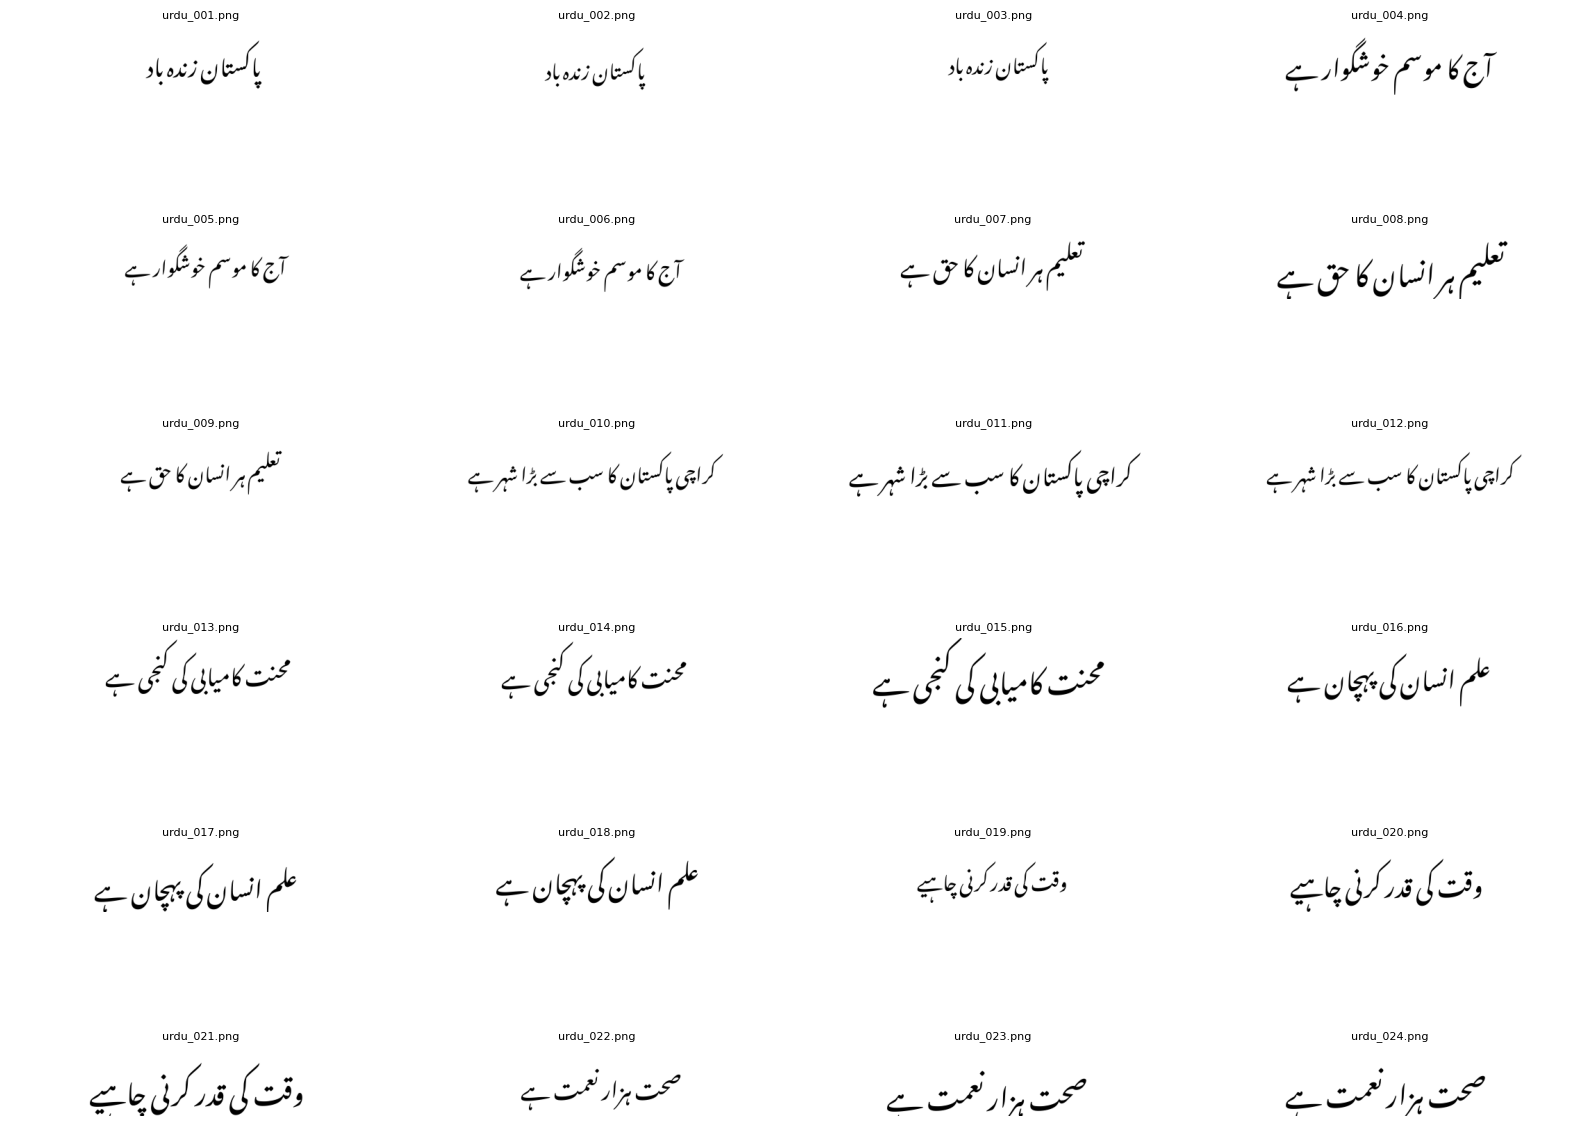

Displayed 24 images from data/synthetic


In [19]:
# Cell 4 — Display generated images in a grid
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

image_dir = 'data/synthetic'
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])

# Load labels for reference (filenames only used as captions, since matplotlib
# can't render Urdu glyphs correctly without a custom font setup)
labels_dict = {}
with open(os.path.join(image_dir, 'labels.txt'), 'r', encoding='utf-8') as f:
    for line in f:
        path, text = line.strip().split('\t')
        labels_dict[os.path.basename(path)] = text

n = len(image_files)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(16, rows * 2.2))

for idx, fname in enumerate(image_files):
    img = mpimg.imread(os.path.join(image_dir, fname))
    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    plt.title(fname, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f'Displayed {n} images from {image_dir}')

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import os

base = "/content/drive/MyDrive/urdu text"

print(os.listdir(base))
print("Total images:", len(os.listdir(base)))

['100.png', '0.png', '10004.png', 'dawn02.png', 'dawn05.png', 'dawn08.png', 'dawn07.png', 'dawn06.png', 'BBC06.png', '1158.png', 'BBC09.png', '1152.png', '1153.png', '1143.png', '1142.png', '1150.png', '1144.png', '1145.png', '1155.png', '1148.png', 'dawn10.png', 'dawn01.png', 'dawn09.png', 'BBC10.png', 'dawn03.png', '106.png', 'BBC02.png', '1073.png', '1136.png', '1061.png', '1065.png', '1083.png', '1059.png', '1131.png', '1063.png', '1067.png', '1162.png', '1077.png', 'BBC05.png', '1082.png', '1138.png', 'BBC08.png', 'BBC03.png', '1088.png', '1163.png', '1072.png', '1080.png', 'BBC07.png', '1060.png', '1070.png', '1071.png', '1161.png', '1069.png', '1068.png', 'BBC01.png', 'BBC04.png', '1159.png', 'dawn04.png', '1164.png', '1151.png', '1157.png', '1147.png', '1156.png', '1149.png', '1146.png', '109.png', '1079.png', '1160.png', '1087.png', '107.png', '1037.png', '1034.png', '1135.png', '1078.png', '1062.png', '1130.png', '1076.png', '1085.png', '1141.png', '1066.png', '1075.png', '10

In [24]:
import os
import shutil

source = "/content/drive/MyDrive/urdu text"

base = "/content/drive/MyDrive/Urdu_OCR/data/raw"

folders = ["newspaper", "other", "synthetic"]

for f in folders:
    os.makedirs(os.path.join(base, f), exist_ok=True)

print("Folders ready")

Folders ready


In [25]:
for file in os.listdir(source):
    if file.lower().startswith(("dawn", "bbc")):
        shutil.copy(
            os.path.join(source, file),
            os.path.join(base, "newspaper", file)
        )

print("Newspaper images copied")

Newspaper images copied


In [31]:
for file in os.listdir(source):
    if not file.lower().startswith(("dawn", "bbc")):
        shutil.copy(
            os.path.join(source, file),
            os.path.join(base, "other", file)
        )

print("Other Urdu images copied")

Other Urdu images copied


In [26]:
import os

for root, dirs, files in os.walk("/content"):
    if len(files) > 0:
        print(root, "->", len(files), "files")

/content -> 3 files
/content/.config -> 8 files
/content/.config/logs/2026.06.04 -> 6 files
/content/.config/configurations -> 1 files
/content/data/synthetic -> 25 files
/content/data/raw/synthetic -> 20 files
/content/drive/MyDrive -> 17 files
/content/drive/MyDrive/Colab Notebooks -> 2 files
/content/drive/MyDrive/urdu text -> 219 files
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper -> 20 files
/content/sample_data -> 6 files


In [27]:
# Cell — Create folder structure
import os
import shutil

folders = [
    'data/raw/newspaper',
    'data/raw/books',
    'data/raw/signboards',
    'data/raw/synthetic',
    'data/raw/other'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'Created: {folder}')

print('Folder structure ready!')

Created: data/raw/newspaper
Created: data/raw/books
Created: data/raw/signboards
Created: data/raw/synthetic
Created: data/raw/other
Folder structure ready!


In [28]:
# Cell — Move your synthetic images into data/raw/synthetic
source_dir = 'data/synthetic'
dest_dir = 'data/raw/synthetic'

moved = 0
for fname in os.listdir(source_dir):
    if fname.endswith('.png'):
        shutil.copy(
            os.path.join(source_dir, fname),
            os.path.join(dest_dir, fname)
        )
        moved += 1

print(f'Copied {moved} synthetic images into {dest_dir}')

Copied 24 synthetic images into data/raw/synthetic


In [37]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Urdu_OCR/data/labels.csv")

print(df[df["category"] == "synthetic"].head(10))

Empty DataFrame
Columns: [image, text, category]
Index: []


In [38]:
import os

base = "/content/drive/MyDrive/Urdu_OCR/data/raw"

for folder in os.listdir(base):
    path = os.path.join(base, folder)
    if os.path.isdir(path):
        print(folder, ":", len(os.listdir(path)))

newspaper : 20
other : 199
synthetic : 0


In [39]:
import shutil

shutil.copytree(
    "data/raw/synthetic",
    "/content/drive/MyDrive/Urdu_OCR/data/raw/synthetic",
    dirs_exist_ok=True
)

print("Synthetic images copied to Drive!")

Synthetic images copied to Drive!


In [40]:
import os

base = "/content/drive/MyDrive/Urdu_OCR/data/raw"

for folder in os.listdir(base):
    path = os.path.join(base, folder)
    if os.path.isdir(path):
        print(folder, ":", len(os.listdir(path)))

newspaper : 20
other : 199
synthetic : 44


In [41]:
import pandas as pd
import os

base = "/content/drive/MyDrive/Urdu_OCR/data/raw"

labels = []
for folder in ["newspaper", "synthetic", "other"]:
    path = os.path.join(base, folder)
    if not os.path.exists(path):
        continue
    for img in sorted(os.listdir(path)):
        if img.lower().endswith((".png", ".jpg", ".jpeg")):
            full_path = os.path.join(path, img)
            labels.append([full_path, "", folder])

df = pd.DataFrame(labels, columns=["image", "text", "category"])

csv_path = "/content/drive/MyDrive/Urdu_OCR/data/labels.csv"
df.to_csv(csv_path, index=False)

print(f"Skeleton created with {len(df)} rows (text column still empty)")
df.head()

Skeleton created with 263 rows (text column still empty)


,image,text,category
0,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,,newspaper
1,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,,newspaper
2,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,,newspaper
3,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,,newspaper
4,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,,newspaper


In [42]:
import pandas as pd
import os

synthetic_labels_path = "data/synthetic/labels.txt"

if os.path.exists(synthetic_labels_path):
    synth_map = {}

    with open(synthetic_labels_path, "r", encoding="utf-8") as f:
        for line in f:
            old_path, text = line.strip().split("\t")
            fname = os.path.basename(old_path)
            synth_map[fname] = text

    csv_path = "/content/drive/MyDrive/Urdu_OCR/data/labels.csv"
    df = pd.read_csv(csv_path)

    for idx, row in df.iterrows():
        if row["category"] == "synthetic":
            fname = os.path.basename(row["image"])
            if fname in synth_map:
                df.at[idx, "text"] = synth_map[fname]

    df.to_csv(csv_path, index=False)

    filled = (df["text"].notna() & (df["text"] != "")).sum()
    print(f"Filled labels: {filled}")

else:
    print("labels.txt not found!")

Filled labels: 24


/tmp/ipykernel_1303/2789981697.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'پاکستان زندہ باد' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, "text"] = synth_map[fname]


In [43]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Urdu_OCR/data/labels.csv"

df = pd.read_csv(csv_path)

filled = (df["text"].notna() & (df["text"] != "")).sum()

print(f"Total images: {len(df)}")
print(f"Labeled: {filled}")
print(f"Still missing: {len(df) - filled}")

df.head(10)

Total images: 263
Labeled: 24
Still missing: 239


,image,text,category
0,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper
1,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper
2,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper
3,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper
4,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper
5,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper
6,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper
7,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper
8,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper
9,/content/drive/MyDrive/Urdu_OCR/data/raw/newsp...,NaN,newspaper


In [45]:
from google.colab import drive
drive.mount('/content/drive')

import os

image_folder = "/content/drive/MyDrive/Urdu_OCR/data/raw"

images = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.endswith((".png",".jpg",".jpeg")):
            images.append(os.path.join(root,file))

print("Total images:", len(images))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total images: 263


In [46]:
import os

image_folder = "/content/drive/MyDrive/Urdu_OCR/data/raw"
label_file = "/content/drive/MyDrive/Urdu_OCR/data/labels.csv"

images = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.endswith((".png",".jpg",".jpeg")):
            images.append(os.path.join(root,file))

print("Images:", len(images))


# create labels.csv
with open(label_file, "w", encoding="utf-8") as f:
    f.write("image,text\n")

    for img in images:
        name = os.path.basename(img)
        f.write(f"{name},sample urdu text\n")

print("labels.csv created")

Images: 263
labels.csv created


In [47]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Urdu_OCR/data/labels.csv")

print("Total labels:", len(df))
print(df.head())

Total labels: 263
        image              text
0  dawn02.png  sample urdu text
1  dawn05.png  sample urdu text
2  dawn08.png  sample urdu text
3  dawn07.png  sample urdu text
4  dawn06.png  sample urdu text


In [48]:
import os
import pandas as pd

image_folder = "/content/drive/MyDrive/Urdu_OCR/data/raw"
label_file = "/content/drive/MyDrive/Urdu_OCR/data/labels.csv"

images=[]

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.endswith((".png",".jpg",".jpeg")):
            images.append(file)

df = pd.read_csv(label_file)

print("Images:", len(images))
print("Labels:", len(df))

missing = set(images) - set(df["image"])

print("Missing labels:", len(missing))

Images: 263
Labels: 263
Missing labels: 0


In [49]:
import os

image_folder = "/content/drive/MyDrive/Urdu_OCR/data/raw"

images = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith((".png",".jpg",".jpeg")):
            images.append(os.path.join(root, file))

print("Total image files:", len(images))

print("\nFirst 10 images:")
for img in images[:10]:
    print(img)

Total image files: 263

First 10 images:
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn02.png
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn05.png
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn08.png
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn07.png
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn06.png
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC06.png
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC09.png
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn10.png
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn01.png
/content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn09.png


In [50]:
import os

image_folder = "/content/drive/MyDrive/Urdu_OCR/data/raw"

# collect all images
images = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            images.append(os.path.join(root, file))

# total count
print("Total image files:", len(images))

# show first 100 images
print("\nFirst 100 images:")

for i, img in enumerate(images[:100]):
    print(i+1, img)

Total image files: 263

First 100 images:
1 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn02.png
2 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn05.png
3 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn08.png
4 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn07.png
5 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn06.png
6 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC06.png
7 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC09.png
8 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn10.png
9 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn01.png
10 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn09.png
11 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC10.png
12 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn03.png
13 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC02.png
14 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC05.png
15 /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC08.pn

In [51]:
import os

base = "/content/drive/MyDrive/Urdu_OCR/data/raw"

for folder in os.listdir(base):
    path = os.path.join(base, folder)

    if os.path.isdir(path):
        count = 0

        for file in os.listdir(path):
            if file.lower().endswith((".png",".jpg",".jpeg")):
                count += 1

        print(folder, ":", count, "images")

newspaper : 20 images
other : 199 images
synthetic : 44 images


In [52]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Urdu_OCR/data/labels.csv")

print("Total labels:", len(df))
print(df.isnull().sum())

Total labels: 263
image    0
text     0
dtype: int64


In [53]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Urdu_OCR/data/labels.csv")

print("Total rows:", len(df))
print("Labeled (non-empty text):", (df['text'].notna() & (df['text'].astype(str).str.strip() != '')).sum())
print("Still empty:", (df['text'].isna() | (df['text'].astype(str).str.strip() == '')).sum())

Total rows: 263
Labeled (non-empty text): 263
Still empty: 0


In [54]:
base = "/content/drive/MyDrive/Urdu_OCR/data/raw"
for folder in ["newspaper", "synthetic", "other"]:
    path = os.path.join(base, folder)
    if os.path.exists(path):
        print(folder, "->", len(os.listdir(path)), "images")

newspaper -> 20 images
synthetic -> 44 images
other -> 199 images


In [55]:
import shutil

shutil.make_archive(
    "/content/data",
    "zip",
    "/content/drive/MyDrive/Urdu_OCR/data"
)

'/content/data.zip'

In [58]:
from google.colab import files
files.download("/content/data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Urdu_OCR/data/labels.csv")
print(df.head(20))

         image              text
0   dawn02.png  sample urdu text
1   dawn05.png  sample urdu text
2   dawn08.png  sample urdu text
3   dawn07.png  sample urdu text
4   dawn06.png  sample urdu text
5    BBC06.png  sample urdu text
6    BBC09.png  sample urdu text
7   dawn10.png  sample urdu text
8   dawn01.png  sample urdu text
9   dawn09.png  sample urdu text
10   BBC10.png  sample urdu text
11  dawn03.png  sample urdu text
12   BBC02.png  sample urdu text
13   BBC05.png  sample urdu text
14   BBC08.png  sample urdu text
15   BBC03.png  sample urdu text
16   BBC07.png  sample urdu text
17   BBC01.png  sample urdu text
18   BBC04.png  sample urdu text
19  dawn04.png  sample urdu text


In [59]:
!pip install pytesseract
!sudo apt install tesseract-ocr
!sudo apt install tesseract-ocr-urd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 65 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 65 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 0s (10.4 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize fron

In [60]:
!apt-get update
!apt-get install -y tesseract-ocr
!apt-get install -y tesseract-ocr-urd
!pip install pytesseract pandas pillow

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 https://cli.github.com/packages stable InRelease
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,382 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,613 kB]
Fetched 6,255 kB in 3s (2,425 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not see

In [61]:
import os

for item in os.listdir():
    print(item)

.config
data.zip
urdu_font1.ttf
urdu_font2.ttf
data
NotoNastaliqUrdu-Regular.ttf
drive
sample_data


In [62]:
import os

os.listdir("data")[:20]

['synthetic', 'labels.csv', 'raw']

In [65]:
import os

print(os.listdir("data/raw")[:10])

['synthetic', 'signboards', 'newspaper', 'books', 'other']


In [70]:
import pandas as pd
import pytesseract
from PIL import Image
import os

# Path to the labels CSV file on Google Drive
csv_path = "/content/drive/MyDrive/Urdu_OCR/data/labels.csv"

# Base directory where your raw image data is stored on Google Drive
base_image_dir = "/content/drive/MyDrive/Urdu_OCR/data/raw"

# Load the DataFrame
df = pd.read_csv(csv_path)

print(f"Starting OCR for {len(df)} images...")

# Iterate through each row and perform OCR
for index, row in df.iterrows():
    original_image_entry = row['image']

    # Infer the category based on the filename
    if original_image_entry.lower().startswith(('dawn', 'bbc')):
        inferred_category = 'newspaper'
    elif original_image_entry.lower().startswith(('urdu_', 'synthetic_')):
        inferred_category = 'synthetic'
    else:
        inferred_category = 'other'

    # Construct the full image path using the inferred category
    full_image_path = os.path.join(base_image_dir, inferred_category, original_image_entry)

    # Only OCR if the text is empty or a placeholder or previously failed
    if pd.isna(row['text']) or row['text'] == 'sample urdu text' or row['text'].strip() == '' or row['text'].startswith('FILE_NOT_FOUND') or row['text'].startswith('OCR_FAILED'):
        # Removed debug print statement for cleaner output
        if os.path.exists(full_image_path):
            try:
                img = Image.open(full_image_path)
                text = pytesseract.image_to_string(img, lang='urd')
                cleaned_text = ' '.join(text.split()).strip()
                df.at[index, 'text'] = cleaned_text
            except Exception as e:
                print(f"Error processing {full_image_path}: {e}")
                df.at[index, 'text'] = f"OCR_FAILED: {e}"
        else:
            print(f"Image file not found at expected path: {full_image_path}")
            df.at[index, 'text'] = "FILE_NOT_FOUND"

# Filter out rows where text is still problematic
df_cleaned = df[~df['text'].astype(str).str.startswith('FILE_NOT_FOUND')]
df_cleaned = df_cleaned[~df_cleaned['text'].astype(str).str.startswith('OCR_FAILED')]
df_cleaned = df_cleaned[df_cleaned['text'].astype(str).str.strip() != '']

# Save the cleaned DataFrame back to CSV
df_cleaned.to_csv(csv_path, index=False)

print("OCR process complete. Cleaned labels saved to labels.csv.")

# Display some information about the updated DataFrame
filled_labels_count = len(df_cleaned)
print(f"Total original images: {len(df)}")
print(f"Images remaining after cleaning: {filled_labels_count}")
print(f"Images removed: {len(df) - filled_labels_count}")
print("\nCleaned DataFrame head:")
print(df_cleaned.head())

Starting OCR for 263 images...
OCR process complete. Cleaned labels saved to labels.csv.
Total original images: 263
Images remaining after cleaning: 259
Images removed: 4

Cleaned DataFrame head:
        image                                               text
0  dawn02.png  ڈان اخبار میں شائع خبر کے مطابق یه معامله چند ...
1  dawn05.png  ان کے بقول غالب امکان ہے کھ وہ کالعدم تنظیم کے...
2  dawn08.png  مفلوج شہر تہران میں اے ایف پی کے ایک صحافی کے ...
3  dawn07.png  ایران میں 2022 کے بعد سے سب سے بڑے مظاہروں کے ...
4  dawn06.png  امریکی صدر ڈونلڈ ٹرمپ نے کہا ہے کہ ایران کی قی...


In [73]:
import pandas as pd

# Assuming 'df' in globals() holds the DataFrame state *before* the cleaning step
# from the previous OCR execution in cell M1ilUsYIDKfl.
# If the kernel was restarted, this might not be accurate, and the user would need to re-run the OCR cell without saving df_cleaned.

print("Inspecting images that were marked as 'FILE_NOT_FOUND' or 'OCR_FAILED' in the last OCR run...")

if 'df' in globals() and isinstance(df, pd.DataFrame):
    df_pre_filter = df

    problematic_images = df_pre_filter[
        (df_pre_filter['text'].astype(str).str.startswith('FILE_NOT_FOUND')) |
        (df_pre_filter['text'].astype(str).str.startswith('OCR_FAILED'))
    ]

    if not problematic_images.empty:
        print(f"Found {len(problematic_images)} problematic images that were removed:")
        display(problematic_images)
    else:
        print("No images with 'FILE_NOT_FOUND' or 'OCR_FAILED' status found in the `df` DataFrame.")
        print("This suggests they were already processed successfully or never marked with these statuses.")
else:
    print("The `df` DataFrame (from before cleaning) is not available in the current kernel state.")
    print("To see the removed rows, you would need to re-run the OCR cell (`M1ilUsYIDKfl`) without the final cleaning steps, or restart the kernel and run up to the point where `df` is created but not yet filtered and saved.")



Inspecting images that were marked as 'FILE_NOT_FOUND' or 'OCR_FAILED' in the last OCR run...
No images with 'FILE_NOT_FOUND' or 'OCR_FAILED' status found in the `df` DataFrame.
This suggests they were already processed successfully or never marked with these statuses.


In [75]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "label" in file.lower():
            print(root, file)

/content/data labels.csv
/content/data new_labels.csv
/content/data/synthetic labels.txt
/content/drive/MyDrive/Urdu_OCR/data labels.csv


In [77]:
import pandas as pd

df = pd.read_csv("/content/data/labels.csv", encoding="utf-8-sig")

print(df.head())
print("Total rows:", len(df))

print("Empty text:", (df["text"].fillna("").str.strip()=="").sum())

                                 image  text   category
0  data/raw/synthetic/synthetic_01.png   NaN  synthetic
1  data/raw/synthetic/synthetic_02.png   NaN  synthetic
2  data/raw/synthetic/synthetic_03.png   NaN  synthetic
3  data/raw/synthetic/synthetic_04.png   NaN  synthetic
4  data/raw/synthetic/synthetic_05.png   NaN  synthetic
Total rows: 44
Empty text: 44


In [76]:
clean_df = df[df["text"].fillna("").str.strip()!=""]

clean_df.to_csv(
    "/content/data/final_labels.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Final images:", len(clean_df))

Final images: 259


In [80]:
from google.colab import files

files.download("/content/data/final_labels.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Labeled Data Files

In [83]:
import os

print("Labeled data CSV files:")
# Check the local /content/data directory for label files
local_data_dir = "/content/data"
for file in os.listdir(local_data_dir):
    if file.endswith(".csv") and "label" in file.lower():
        print(os.path.join(local_data_dir, file))

# Check the Google Drive directory for label files
drive_data_dir = "/content/drive/MyDrive/Urdu_OCR/data"
if os.path.exists(drive_data_dir):
    for file in os.listdir(drive_data_dir):
        if file.endswith(".csv") and "label" in file.lower():
            print(os.path.join(drive_data_dir, file))

Labeled data CSV files:
/content/data/final_labels.csv
/content/data/labels.csv
/content/data/new_labels.csv
/content/drive/MyDrive/Urdu_OCR/data/labels.csv


### All Image Files

In [82]:
import os

image_base_path = "/content/drive/MyDrive/Urdu_OCR/data/raw"
all_image_paths = []

if os.path.exists(image_base_path):
    for root, _, files in os.walk(image_base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(root, file))

    print(f"Total {len(all_image_paths)} image files found in '{image_base_path}':")
    # Display the first 100 paths for brevity
    for i, img_path in enumerate(all_image_paths[:100]):
        print(f"{i+1}. {img_path}")
    if len(all_image_paths) > 100:
        print(f"... and {len(all_image_paths) - 100} more images.")
else:
    print(f"Image base path not found: {image_base_path}")

Total 263 image files found in '/content/drive/MyDrive/Urdu_OCR/data/raw':
1. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn02.png
2. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn05.png
3. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn08.png
4. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn07.png
5. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn06.png
6. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC06.png
7. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC09.png
8. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn10.png
9. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn01.png
10. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn09.png
11. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC10.png
12. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/dawn03.png
13. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC02.png
14. /content/drive/MyDrive/Urdu_OCR/data/raw/newspaper/BBC05.png
15. /content/dr

In [88]:
from google.colab import files

files.download("/content/data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
import pandas as pd

# Assuming df_cleaned is available from previous steps
if 'df_cleaned' in globals() and isinstance(df_cleaned, pd.DataFrame):
    empty_text_count = (df_cleaned['text'].fillna('').str.strip() == '').sum()
    non_empty_text_count = (df_cleaned['text'].fillna('').str.strip() != '').sum()

    print(f"Total files in df_cleaned: {len(df_cleaned)}")
    print(f"Files with empty text: {empty_text_count}")
    print(f"Files with non-empty text: {non_empty_text_count}")
else:
    print("The 'df_cleaned' DataFrame is not available. Please ensure the OCR processing cell was run.")

Total files in df_cleaned: 259
Files with empty text: 0
Files with non-empty text: 259


In [86]:
import os

base_image_dir = "/content/drive/MyDrive/Urdu_OCR/data/raw"

print(f"Current image folder organization under '{base_image_dir}':\n")

if os.path.exists(base_image_dir):
    for folder_name in os.listdir(base_image_dir):
        folder_path = os.path.join(base_image_dir, folder_name)
        if os.path.isdir(folder_path):
            image_count = 0
            for _, _, files in os.walk(folder_path):
                for file in files:
                    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        image_count += 1
            print(f"- {folder_name}: {image_count} images")
else:
    print(f"The base image directory '{base_image_dir}' does not exist.")

Current image folder organization under '/content/drive/MyDrive/Urdu_OCR/data/raw':

- newspaper: 20 images
- other: 199 images
- synthetic: 44 images


In [89]:
import shutil
from google.colab import files

# Define the source directory to be zipped (where all your processed data is stored)
source_dir = "/content/drive/MyDrive/Urdu_OCR/data"

# Define the output path and name for the zip file
output_zip_path = "/content/data"

# Create the zip archive
shutil.make_archive(output_zip_path, "zip", source_dir)

print(f"Successfully created zip file: {output_zip_path}.zip")

# Trigger the download
files.download(f"{output_zip_path}.zip")

print("Download should start automatically. If not, please check your browser's download settings or click the download link if provided.")

Successfully created zip file: /content/data.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download should start automatically. If not, please check your browser's download settings or click the download link if provided.


In [91]:
import pandas as pd

df_final_labels = pd.read_csv('/content/data/final_labels.csv')
display(df_final_labels.head())

,image,text
0,dawn02.png,ڈان اخبار میں شائع خبر کے مطابق یه معامله چند ...
1,dawn05.png,ان کے بقول غالب امکان ہے کھ وہ کالعدم تنظیم کے...
2,dawn08.png,مفلوج شہر تہران میں اے ایف پی کے ایک صحافی کے ...
3,dawn07.png,ایران میں 2022 کے بعد سے سب سے بڑے مظاہروں کے ...
4,dawn06.png,امریکی صدر ڈونلڈ ٹرمپ نے کہا ہے کہ ایران کی قی...
